#  SIMPLE LINEAR REGRESSION


## MODUL 1: DATA SEDERHANA

### Import Library

In [23]:
#%%
import numpy as np  # untuk perhitungan saintifik
import matplotlib.pyplot as plt  # untuk plotting
from sklearn.linear_model import LinearRegression

###  Membuat Data Sembarang 

In [24]:
#%%
penjualan = np.array([6,5,5,4,4,3,2,2,2,1])
harga = np.array([16000, 18000, 27000, 34000, 50000, 68000, 65000, 81000, 85000, 90000])

###  Menampilkan Data

In [25]:
#%%
print("Data Penjualan :", penjualan)
print("Data Harga :", harga)

Data Penjualan : [6 5 5 4 4 3 2 2 2 1]
Data Harga : [16000 18000 27000 34000 50000 68000 65000 81000 85000 90000]


###  Visualisasi Data

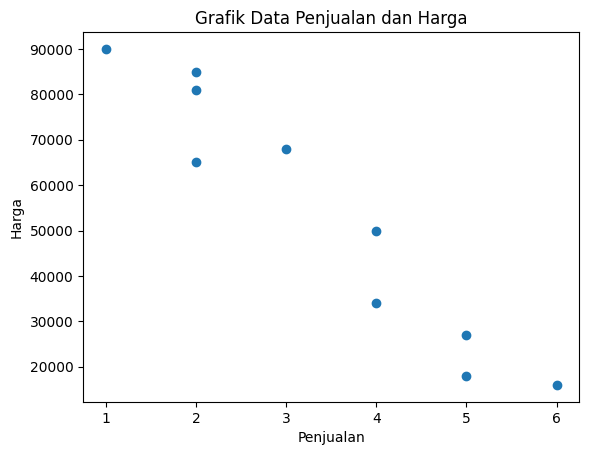

In [26]:
#%%
plt.scatter(penjualan, harga)
plt.title("Grafik Data Penjualan dan Harga")
plt.xlabel("Penjualan")
plt.ylabel("Harga")
plt.show()

###  Membuat Model Regresi

In [27]:
#%%
penjualan = penjualan.reshape(-1,1)
linreg = LinearRegression()
linreg.fit(penjualan, harga)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


###  Visualisasi Hasil Regresi

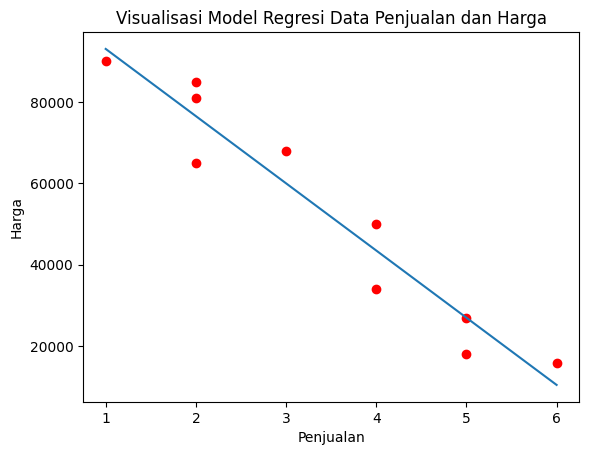

In [28]:
#%%
plt.scatter(penjualan, harga, color='red')
plt.plot(penjualan, linreg.predict(penjualan))
plt.title("Visualisasi Model Regresi Data Penjualan dan Harga")
plt.xlabel("Penjualan")
plt.ylabel("Harga")
plt.show()

##  MODUL 2: DATASET

### Import Library

In [29]:
#%%
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

### Load Dataset

In [30]:
#%%
df = pd.read_csv("FuelConsumptionCo2.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


###  Seleksi Data

In [31]:
#%%
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_CITY','CO2EMISSIONS']]
cdf.head(9)
# %%

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,CO2EMISSIONS
0,2.0,4,9.9,196
1,2.4,4,11.2,221
2,1.5,4,6.0,136
3,3.5,6,12.7,255
4,3.5,6,12.1,244
5,3.5,6,11.9,230
6,3.5,6,11.8,232
7,3.7,6,12.8,255
8,3.7,6,13.4,267


###  Visualisasi Fuel vs Emission

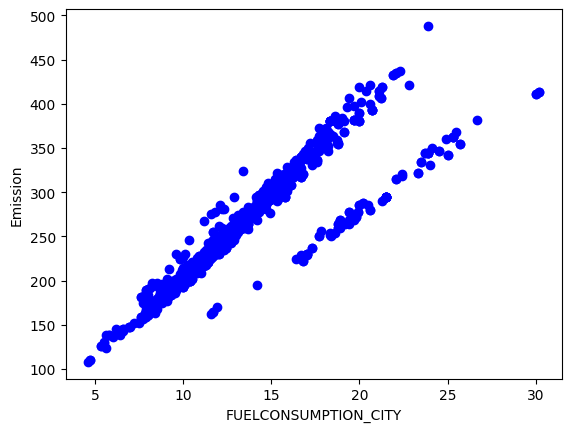

In [32]:
#%%
plt.scatter(cdf.FUELCONSUMPTION_CITY, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("FUELCONSUMPTION_CITY")
plt.ylabel("Emission")
plt.show()


###  Visualisasi Engine Size vs Emission

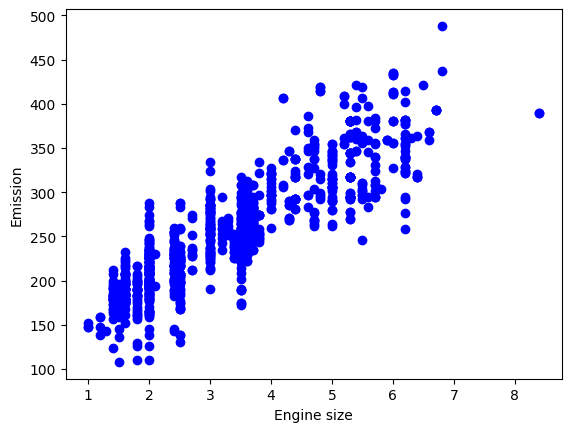

In [33]:
#%%
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()
# %%


###  Split Data

In [34]:
#%%
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

###  Visualisasi Data Training

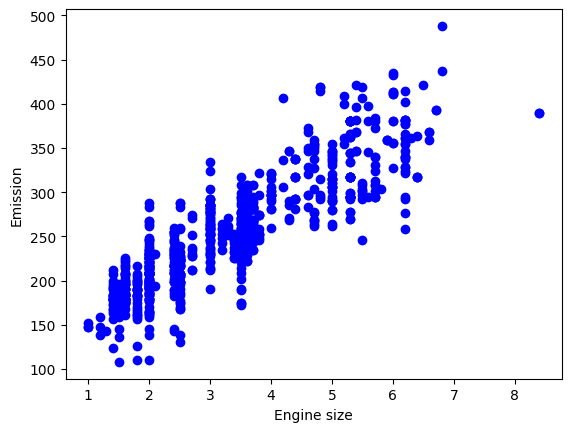

In [35]:
#%%
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

###  Membuat Model Regresi

In [36]:
#%%
regr = LinearRegression()
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
regr.fit (train_x, train_y)

print ('Coefficients: ', regr.coef_)
print ('Intercept: ',regr.intercept_)
# %%

Coefficients:  [[38.79727263]]
Intercept:  [126.12255576]


###  Visualisasi Hasil Regresi

Text(0, 0.5, 'Emission')

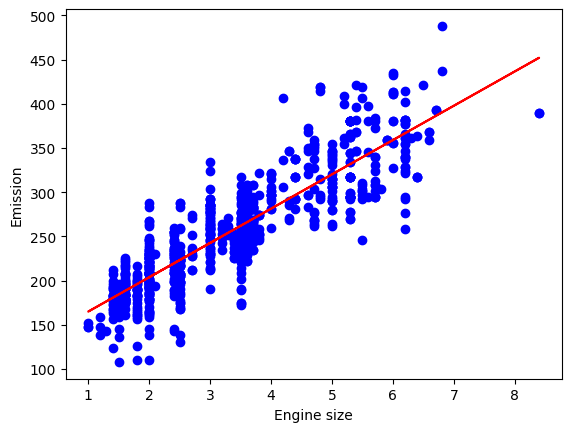

In [37]:
#%%
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")